# Exporting Final Masked Data Cube to Blender
---
## 3.1 Aim
This notebook prepares the final masked data cube for export to Blender. 

**Procedure:**
> 1. Load the final masked cube
> 2. Verify that the masked cube shape matches emission mask
> 3. Extract each voxel's spatial position, velocity and original H I brightness
> 4. Convert the P-P-V coordinates into centered + scaled Blender coordinates
> 5. Keep the original intensity and create display-intensity
> 6. Export full and preview `.npz` products, preview P-P-V projection in jupyter

## 3.2 Setup and data loading

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import pandas as pd

from spectral_cube import SpectralCube
from astropy.io import fits

In [2]:
inputFolder = Path("outputs")
cubeFile = inputFolder / "NGC3741_masked_cube.fits"

exportFolder = Path("blender_exports")
exportFolder.mkdir(parents=True, exist_ok=True)

Reading: /Users/elsawang/Documents/visualization/radio_data/outputs/NGC3741_masked_cube.fits
Exporting to: /Users/elsawang/Documents/visualization/radio_data/blender_exports


In [3]:
finalCube = SpectralCube.read(cubeFile)

print("Cube shape:", finalCube.shape)
print("Brightness unit:", finalCube.unit)
print("Velocity range:", finalCube.spectral_axis.min().to(u.km / u.s),
      "to", finalCube.spectral_axis.max().to(u.km / u.s))

Cube shape: (102, 500, 400)
Brightness unit: Jy / beam
Velocity range: 164.50392515172268 km / s to 294.81457583187955 km / s


## 3.3 Extract the retained H I voxels

In [4]:
# load the brightness measurements (create 3D NumPy array with shape (velocity channel, y pixel, x pixel)
cubeData = finalCube.filled_data[:].value

# keep finite H I measurements, create Bool array with same shape as cube
maskData = fits.getdata(inputFolder / "NGC3741_emission_mask.fits").astype(bool)
validVoxels = maskData

# find location of every retained voxel (where validVoxels is True)
channelIndex, yPixel, xPixel = np.nonzero(validVoxels)
#returns 3 equal-length arrays 

# extract the original brightness at those locations
intensityJyBeam = cubeData[validVoxels].astype(np.float32)

# convert each channel index into its physical velocity
velocityAxis = finalCube.spectral_axis.to_value(u.km / u.s) 
velocityKms = velocityAxis[channelIndex].astype(np.float32)

print("Total cube voxels:", cubeData.size)
print("Retained H I voxels:", len(intensityJyBeam))

Total cube voxels: 20400000
Retained H I voxels: 673200


In [5]:
assert maskData.shape == cubeData.shape
assert np.isfinite(cubeData[maskData]).all(), (
    "invalid cube values"
)
# VERIFY THAT THE SHAPES MATCH

In [6]:
voxelTable = pd.DataFrame({
    "x_pixel": xPixel,
    "y_pixel": yPixel,
    "channel": channelIndex,
    "velocity_kms": velocityKms,
    "intensity_jybeam": intensityJyBeam
})

voxelTable.head()

,x_pixel,y_pixel,channel,velocity_kms,intensity_jybeam
0,312,104,7,173.531708,0.002122
1,313,104,7,173.531708,0.001815
2,314,104,7,173.531708,0.001757
3,315,104,7,173.531708,0.002037
4,312,105,7,173.531708,0.002152


## 3.4 Create Blender coordinates

In [7]:
nChannels, nY, nX = finalCube.shape

# center the spatial coordinates
xCentered = xPixel - (nX-1)/2
yCentered = yPixel - (nY-1)/2

# make largest spatial dimension approximately 10 Blender units wide
spatialW = 10.0
spatialScale = spatialW / max(nX, nY)

xBlender = (xCentered * spatialScale).astype(np.float32)
yBlender = (yCentered * spatialScale).astype(np.float32)

# center the velocity axis
velocityCenter = (velocityAxis.min() + velocityAxis.max()) / 2

# give velocity axis a displayed depth of approximately 10 Blender units
velocityD = 10.0
velocityScale = velocityD / np.ptp(velocityAxis) #peak-to-peak

zBlender = ((velocityKms - velocityCenter) * velocityScale).astype(np.float32)

print("Velocity is visualized as the z-axis in Blender")
print("Velocity center:", velocityCenter, "km/s")

Velocity is visualized as the z-axis in Blender
Velocity center: 229.65925049180112 km/s


## 3.5 Normalization (display-intensity scale) of a physical property

In [8]:
intensityLow = np.nanpercentile(intensityJyBeam, 1)
intensityHigh = np.nanpercentile(intensityJyBeam, 99.5)

intensityLinear = np.clip((intensityJyBeam - intensityLow)/(intensityHigh - intensityLow), 0, 1)

# square root scaling so faint emission is easier to see
intensityDisplay = np.sqrt(intensityLinear).astype(np.float32)

print("Original intensity range:",
      intensityJyBeam.min(), "to", intensityJyBeam.max(),
      finalCube.unit)

print("Display intensity range:",
      intensityDisplay.min(), "to", intensityDisplay.max())

Original intensity range: -0.0021412089 to 0.010641894 Jy / beam
Display intensity range: 0.0 to 1.0


### Save compressed `.npz` file 

In [9]:
fullExportFile = exportFolder / "NGC3741_blender_full.npz"

np.savez_compressed(
    fullExportFile,

    # blender coordinates
    x=xBlender,
    y=yBlender,
    z=zBlender,

    # original cube coordinates
    x_pixel=xPixel.astype(np.int16),
    y_pixel=yPixel.astype(np.int16),
    channel=channelIndex.astype(np.int16),

    # scientific values
    velocity_kms=velocityKms,
    intensity_jybeam=intensityJyBeam,

    # value for visual appearance
    intensity_display=intensityDisplay
)
print("Full points:", len(intensityJyBeam))

Full points:
Saved: /Users/elsawang/Documents/visualization/radio_data/blender_exports/NGC3741_blender_full.npz


In [10]:
maximumPreviewPoints = 300_000
numberOfVoxels = len(intensityJyBeam)

if numberOfVoxels > maximumPreviewPoints:
    randomGenerator = np.random.default_rng(seed=3741)

    selected = randomGenerator.choice(
        numberOfVoxels,
        size=maximumPreviewPoints,
        replace=False
    )
else:
    selected = np.arange(numberOfVoxels)

previewExportFile = exportFolder / "NGC3741_blender_preview.npz"

np.savez_compressed(
    previewExportFile,
    x=xBlender[selected],
    y=yBlender[selected],
    z=zBlender[selected],
    velocity_kms=velocityKms[selected],
    intensity_jybeam=intensityJyBeam[selected],
    intensity_display=intensityDisplay[selected]
)

print("Preview points:", len(selected))

Preview points: 300000
Saved: /Users/elsawang/Documents/visualization/radio_data/blender_exports/NGC3741_blender_preview.npz


In [11]:
for filePath in [fullExportFile, previewExportFile]:
    with np.load(filePath) as data:
        print(
            filePath.name,
            "| points:", len(data["x"]),
            "| size:", round(filePath.stat().st_size / 1e6, 2), "MB",
        )

NGC3741_blender_full.npz | points: 673200 | size: 4.93 MB
NGC3741_blender_preview.npz | points: 300000 | size: 3.8 MB


### Check data before export

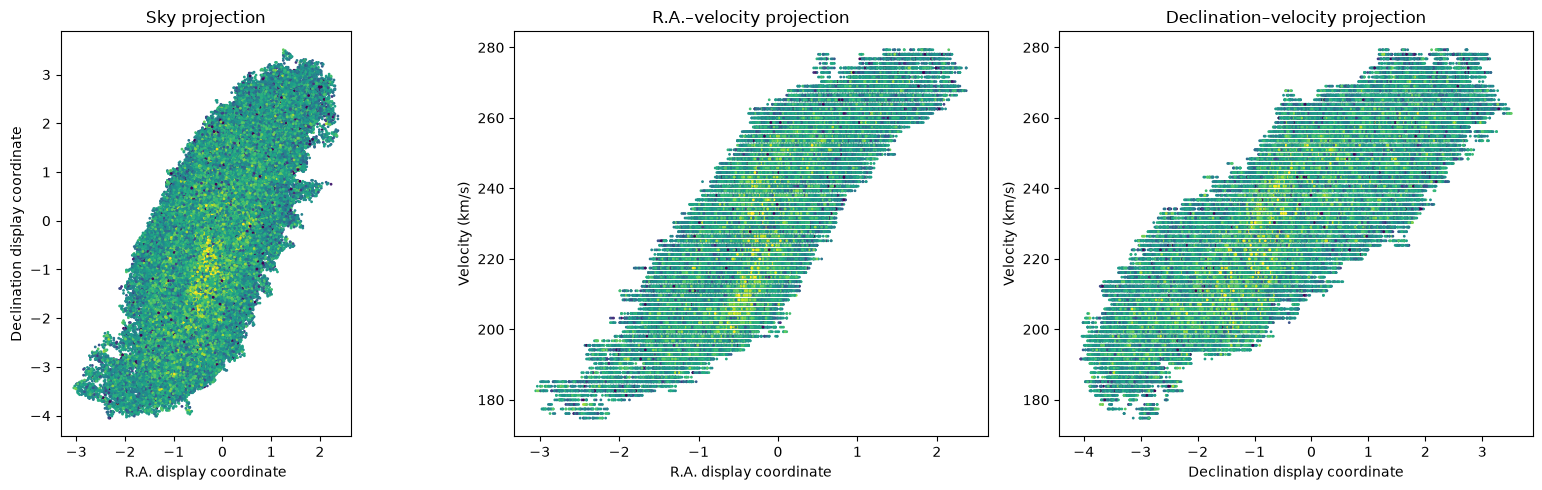

In [12]:
# limit the plot size so Jupyter does not struggle
plotSelection = selected[:100_000]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(
    xBlender[plotSelection],
    yBlender[plotSelection],
    c=intensityDisplay[plotSelection],
    s=1,
    cmap="viridis"
)
axes[0].set_title("Sky projection")
axes[0].set_xlabel("R.A. display coordinate")
axes[0].set_ylabel("Declination display coordinate")
axes[0].set_aspect("equal")

axes[1].scatter(
    xBlender[plotSelection],
    velocityKms[plotSelection],
    c=intensityDisplay[plotSelection],
    s=1,
    cmap="viridis"
)
axes[1].set_title("R.A.–velocity projection")
axes[1].set_xlabel("R.A. display coordinate")
axes[1].set_ylabel("Velocity (km/s)")

axes[2].scatter(
    yBlender[plotSelection],
    velocityKms[plotSelection],
    c=intensityDisplay[plotSelection],
    s=1,
    cmap="viridis"
)
axes[2].set_title("Declination–velocity projection")
axes[2].set_xlabel("Declination display coordinate")
axes[2].set_ylabel("Velocity (km/s)")

plt.tight_layout()
plt.show()